# PyVBMC Example 7: Stacking the posteriors of several runs (S-VBMC)

In this notebook, we combine the variational posteriors of several independent PyVBMC runs into a single *stacked posterior* with S-VBMC (Stacking Variational Bayesian Monte Carlo; Silvestrin, Li & Acerbi, 2025).

Running PyVBMC several times from different starting points is standard practice to check that the runs agree (see Example 4). When they do not, for instance because the posterior is multimodal and each run captures only some of the modes, S-VBMC pools the mixture components of all runs and optimizes their weights against the *stacked ELBO*, using the expected log-joint statistics that every run already stores. Stacking therefore needs **no further evaluations of the model**.

This notebook is Part 7 of a series of notebooks in which we present various example usages for VBMC with the PyVBMC package. S-VBMC needs the optional `torch` dependency: install it with `pip install "pyvbmc[torch]"` (see the installation instructions for a CPU-only torch).

In [1]:
import numpy as np
import scipy.stats as scs
from scipy.special import logsumexp
import matplotlib.pyplot as plt

from pyvbmc import VBMC, SVBMC
from pyvbmc.svbmc.utils import find_init_bounds, overlay_corner_plot

## 1. Model definition: a bimodal target

We take a two-dimensional target with two well-separated modes, an equal mixture of two Gaussians, as a stand-in for a multimodal posterior. Since we know the target, we can later compare the individual runs and the stacked posterior against ground-truth samples. As usual, PyVBMC only needs the unnormalized log density (the log-joint), here defined directly.

In [2]:
D = 2
modes = np.array([[-2.5, -2.5], [2.5, 2.5]])
mode_sd = 0.8


def log_joint(x):
    x = np.atleast_2d(x)
    log_comps = np.stack(
        [scs.norm.logpdf(x, m, mode_sd).sum(axis=1) for m in modes], axis=1
    )
    return logsumexp(log_comps, axis=1) + np.log(0.5)


def sample_truth(n, rng):
    which = rng.integers(len(modes), size=n)
    return modes[which] + mode_sd * rng.standard_normal((n, D))


LB = np.full((1, D), -10.0)  # hard bounds
UB = np.full((1, D), 10.0)
PLB = np.full((1, D), -5.0)  # plausible bounds
PUB = np.full((1, D), 5.0)

## 2. Run PyVBMC several times

We start each run from a different random point in the plausible box. `find_init_bounds` returns the box to draw starting points from (the plausible bounds when given, else the bounds). We run four times with different seeds and keep the returned posteriors. Each posterior carries the run's ELBO estimate and its uncertainty, whether PyVBMC judged the run converged (`stable`), and the expected log-joint statistics that stacking needs. S-VBMC keeps only the converged runs whose expected log-joint is precise enough, and uses their ELBOs to initialize the weights.

In [3]:
n_runs = 4
rng = np.random.default_rng(0)
sample_lb, sample_ub = find_init_bounds(LB, UB, PLB, PUB)

vps = []
for i in range(n_runs):
    x0 = rng.uniform(sample_lb, sample_ub, size=(1, D))
    vbmc = VBMC(
        log_joint, x0, LB, UB, PLB, PUB, options={"display": "off"}, seed=i
    )
    vp, results = vbmc.optimize()
    vps.append(vp)
    print(
        f"Run {i}: x0 = {np.round(x0.ravel(), 2)}, "
        f"ELBO = {vp.stats['elbo']:.3f} +/- {vp.stats['elbo_sd']:.3f}, "
        f"converged: {vp.stats['stable']}"
    )

Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -0.693 +/-0.001.


Run 0: x0 = [ 1.37 -2.3 ], ELBO = -0.693 +/- 0.001, converged: True


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -0.694 +/-0.001.


...

Estimated ELBO: -0.695 +/-0.001.


Run 2: x0 = [3.13 4.13], ELBO = -0.695 +/- 0.001, converged: True


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -0.007 +/-0.001.


Run 3: x0 = [1.07 2.29], ELBO = -0.007 +/- 0.001, converged: True


The target is normalized, so its log evidence is 0. A run that captures a single mode misses half of the probability mass and reports an ELBO close to $\log(1/2) \approx -0.69$; a run that captures both modes reports an ELBO close to 0. Every run is converged by PyVBMC's criteria, which judge the stability of the solution found, not whether every mode was found: this is exactly the situation stacking is for.

## 3. Stack the posteriors

`SVBMC` takes the list of posteriors. It discards runs that did not converge or whose expected log-joint is too uncertain (`s_max`), and raises an error if fewer than `M_min` runs remain (by default two thirds of the runs). `optimize()` maximizes the stacked ELBO with respect to the weights of all pooled components (`version="all-weights"`, the default; `"posterior-only"` optimizes one weight per run instead, and `"ns"` skips the optimization and just averages the runs). It works in place and returns `None`.

The `seed` argument fixes the object's random generator, which drives the Monte Carlo entropy estimate and the sampling below; the input posteriors are never modified.

In [4]:
stacked = SVBMC(vps, seed=0)
stacked.optimize()

print("Stacked ELBO (estimated):", round(stacked.elbo["estimated"], 3))
print(
    "Stacked ELBO (debiased):  ", round(stacked.elbo["debiased_I_median"], 3)
)

# Total weight assigned to each retained run:
offsets = np.concatenate([[0], np.cumsum(stacked.K)])
for m in range(stacked.M):
    share = stacked.w[0, offsets[m] : offsets[m + 1]].sum()
    print(f"Run {m}: total weight {share:.3f}")

Got 4 well-converged runs after filters.


Optimizing the stacked ELBO w.r.t. all weights.


Initial elbo = 0.009763299805292114


iter 5: elbo = 0.045655750816943286


iter 10: elbo = 0.04411824387271546


Stacked ELBO (estimated): 0.046
Stacked ELBO (debiased):   0.019
Run 0: total weight 0.253
Run 1: total weight 0.158
Run 2: total weight 0.171
Run 3: total weight 0.418


The `"estimated"` value is the maximized stacked ELBO; the reference for this target is the true log evidence, 0. Because maximizing a noisy Monte Carlo estimate is optimistically biased, `stacked.elbo` also holds two debiased values that cap the expected log-joint at the median component (`"debiased_I_median"`) and the median run (`"debiased_E_median"`) values; the debiased values are the safer estimates of the log model evidence.

## 4. Sample from the stacked posterior

Each run works in its own transformed parameter space, so the mixture components of different runs are **not** directly comparable and the stacked posterior is not a single Gaussian mixture in the original space. Always use `stacked.sample(n)` for estimates and plots: it returns `n` independent draws in the original parameter space (a run is picked at random by its total weight, then a point from that run's components under the optimized weights).

Below we compare samples from the individual runs, from the stacked posterior and from the true target with `overlay_corner_plot`.

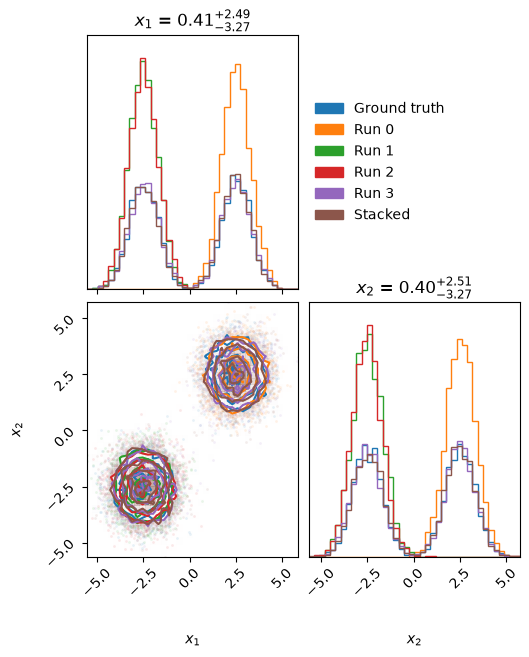

In [5]:
n_samples = 5000
samples = [sample_truth(n_samples, rng)]
labels = ["Ground truth"]
for vp in stacked.vp_list:  # the runs that passed the filters
    samples.append(vp.sample(n_samples)[0])
    labels.append(f"Run {vps.index(vp)}")
samples.append(stacked.sample(n_samples))
labels.append("Stacked")

fig = overlay_corner_plot(samples, labels=labels, figsize=(7, 7), bins=40)

A run that found a single mode places all of its mass there, while the stacked posterior recovers both modes in the right proportions. `stacked.plot()` draws the corner plot of the stacked posterior alone:

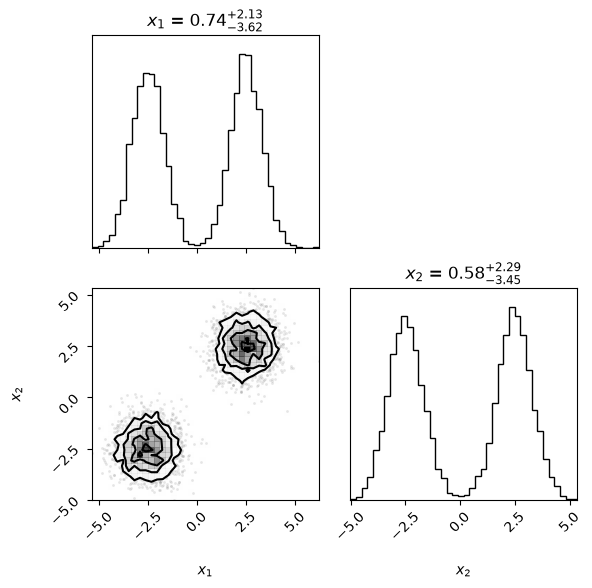

In [6]:
fig = stacked.plot(n_samples=n_samples, figsize=(6, 6), bins=40)

## 5. Conclusions

- Run PyVBMC several times on the same model and data, then pass the returned posteriors to `SVBMC` and call `optimize()`; the stacked posterior needs no new model evaluations.
- Read the estimate of the log model evidence from `stacked.elbo`, preferring the debiased values, and obtain estimates and plots from `stacked.sample()`.
- The runs must describe the same model, data and parameter space; the object cannot check this.
- `stacked.sample(n, balance_flag=True)` splits the draws across runs and components in exact proportion to the weights (a stratified sample with lower variance for expectations, not an independent one).

For details, see the S-VBMC paper: Silvestrin, F., Li, C., & Acerbi, L. (2025). Stacking Variational Bayesian Monte Carlo. *Transactions on Machine Learning Research*. [arXiv:2504.05004](https://arxiv.org/abs/2504.05004). Please cite it together with the VBMC and PyVBMC papers when you use S-VBMC.

## Acknowledgments

Work on the PyVBMC package was funded by the [Finnish Center for Artificial Intelligence FCAI](https://fcai.fi/).